In [1]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, ToolMessage
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
import re
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3

from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
import requests
from pydantic import BaseModel, Field
from typing import Literal, Optional, Union, List
from langchain_google_community import CalendarToolkit
from langchain_google_community.calendar.create_event import CalendarCreateEvent

from datetime import datetime

from langchain_google_community import GmailToolkit
import json
import operator
import os
from groq import Groq



c:\Work_Projects\Agentic_AI_11_04_2026\MyChatBot\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from google_auth_oauthlib.flow import InstalledAppFlow
from google.oauth2.credentials import Credentials
import os

SCOPES = [
    "https://www.googleapis.com/auth/gmail.send",
    "https://www.googleapis.com/auth/calendar",
]

creds = None

# Load existing token
if os.path.exists("token.json"):
    creds = Credentials.from_authorized_user_file("token.json", SCOPES)

# If not valid → login again
if not creds or not creds.valid:
    flow = InstalledAppFlow.from_client_secrets_file(
        "credentials.json",
        SCOPES
    )
    creds = flow.run_local_server(port=0)

    # Save token
    with open("token.json", "w") as token:
        token.write(creds.to_json())

Please visit this URL to authorize this application: https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=509758089312-pnrh4mghsvo6j90j81709mnmvvd1sfn0.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A49768%2F&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fgmail.send+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcalendar&state=unkneeaT8qr5Iuar587Wleu5aKig6t&code_challenge=YbYKNrcyGXWCRf353jpkaCEIJGPwi2d0a6HPJrXtBOY&code_challenge_method=S256&access_type=offline


In [3]:
Cal_toolkit = CalendarToolkit(credentials=creds)
Cal_tools = Cal_toolkit.get_tools()

GM_toolkit = GmailToolkit(credentials=creds)
GM_tools = GM_toolkit.get_tools()
Cal_tools, GM_tools

([CalendarCreateEvent(api_resource=<googleapiclient.discovery.Resource object at 0x000001CFDF807380>),
  CalendarSearchEvents(api_resource=<googleapiclient.discovery.Resource object at 0x000001CFDF807380>),
  CalendarUpdateEvent(api_resource=<googleapiclient.discovery.Resource object at 0x000001CFDF807380>),
  GetCalendarsInfo(api_resource=<googleapiclient.discovery.Resource object at 0x000001CFDF807380>),
  CalendarMoveEvent(api_resource=<googleapiclient.discovery.Resource object at 0x000001CFDF807380>),
  CalendarDeleteEvent(api_resource=<googleapiclient.discovery.Resource object at 0x000001CFDF807380>),
  GetCurrentDatetime(api_resource=<googleapiclient.discovery.Resource object at 0x000001CFDF807380>)],
 [GmailCreateDraft(api_resource=<googleapiclient.discovery.Resource object at 0x000001CFDF856850>),
  GmailSendMessage(api_resource=<googleapiclient.discovery.Resource object at 0x000001CFDF856850>),
  GmailSearch(api_resource=<googleapiclient.discovery.Resource object at 0x000001CF

In [4]:
tools= Cal_tools+GM_tools
tools

[CalendarCreateEvent(api_resource=<googleapiclient.discovery.Resource object at 0x000001CFDF807380>),
 CalendarSearchEvents(api_resource=<googleapiclient.discovery.Resource object at 0x000001CFDF807380>),
 CalendarUpdateEvent(api_resource=<googleapiclient.discovery.Resource object at 0x000001CFDF807380>),
 GetCalendarsInfo(api_resource=<googleapiclient.discovery.Resource object at 0x000001CFDF807380>),
 CalendarMoveEvent(api_resource=<googleapiclient.discovery.Resource object at 0x000001CFDF807380>),
 CalendarDeleteEvent(api_resource=<googleapiclient.discovery.Resource object at 0x000001CFDF807380>),
 GetCurrentDatetime(api_resource=<googleapiclient.discovery.Resource object at 0x000001CFDF807380>),
 GmailCreateDraft(api_resource=<googleapiclient.discovery.Resource object at 0x000001CFDF856850>),
 GmailSendMessage(api_resource=<googleapiclient.discovery.Resource object at 0x000001CFDF856850>),
 GmailSearch(api_resource=<googleapiclient.discovery.Resource object at 0x000001CFDF856850>),

In [5]:
from dotenv import load_dotenv
load_dotenv()
llm_plain = ChatGroq(
    model="qwen/qwen3-32b",
)

In [35]:
class ActionItem(BaseModel):
    title: str = Field(description="title of the task")
    task: str = Field(description="a detailed task description")
    assignee: Optional[str] = Field(default=None, description="Specific person responsible for the task; avoid vague terms like 'team' unless explicitly stated")
    deadline: Optional[str] = Field(default=None, description="Deadline or time reference for the task or event time etc., if any")
    type: str = Field(description="Type of action: email | meeting | reminder | general")
    priority: Literal["low", "medium", "high"] = Field(default="medium", description="Priority level of the task")


class ExtractedData(BaseModel):
    summary: str = Field(
        description=(
        "Write a structured meeting summary with the following sections:\n"
        "- Topics Discussed\n"
        "- Key Decisions\n"
        "- Outcomes / Next Steps\n\n"
        "Keep it concise, factual, and avoid adding information not present in the meeting."
        )
    )

    participants: List[str] = Field(
        description=(
        "List of participant names exactly as mentioned in the meeting. "
        "Use full names if available. Avoid abbreviations unless explicitly used."
        )
    )
    
    action_items: List[ActionItem] = Field(
        default_factory=list,
        description="List of clearly defined actionable tasks from the meeting. Return an empty list if none exist."
    )


class GraphState(dict):
    transcript: Optional[str]
    audio_file: Optional[str]
    transcript_format: str
    summary: Optional[str]
    action_items: Optional[List[dict]]
    participants: Optional[List[str]]
    
    messages: Annotated[list[BaseMessage], add_messages]
    final_summary: str

In [36]:
# Tool-enabled LLM 
llm_with_tools = llm_plain.bind_tools(tools)

# plain LLM with str output
structured_llm = llm_plain.with_structured_output(ExtractedData)

In [37]:
def transcribe(state):
    filename= state["audio_file"]
    client = Groq(api_key=os.getenv("GROQ_API_KEY"))
    with open(filename, "rb") as file:
        transcription = client.audio.transcriptions.create(
            file=(filename, file.read()),
            model="whisper-large-v3",
            temperature=0,
            response_format="verbose_json",
        )
    return {"transcript": transcription.text}

In [38]:
template = ChatPromptTemplate(
    [
        ("system", """You are an AI agent with access to tools.

GENERAL RULES:
- Do NOT include any <think> tags
- Do NOT show reasoning
- Be concise and action-oriented
- Use tools whenever required to complete tasks
- Do NOT assume missing information

WORKFLOW:
1. Carefully analyze the provided action items
2. For each action item, decide required actions
3. Execute actions using tools step-by-step

PARTICIPANT HANDLING:
- assignee_email is already provided when available
- Do NOT attempt to resolve emails again

TIME HANDLING:
- If any action involves date/time → MUST call get_current_datetime FIRST
- Normalize relative times (e.g., "tomorrow", "next week") before using tools

ACTION RULES:
For each action item:
- If assignee exists AND email is resolved → send email using Gmail tool
- If type == "meeting" → create calendar event
- If deadline exists → create calendar reminder
- If multiple conditions apply → perform ALL relevant actions

FAILURE HANDLING:
- If required information is missing → skip that action
- Do NOT guess or hallucinate missing fields
- Continue processing remaining action items

OUTPUT:
- Only return tool outputs or final concise confirmations
"""),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

In [39]:
def get_email_from_db(name: str):
    db = {
        "rohit jangir": "rohit@example.com",
        "ankit sharma": "ankit@example.com",
    }
    return db.get(name.lower().strip(), "22B1502@iitb.ac.in")

In [40]:
def extract_node(state: GraphState):
    result: ExtractedData = structured_llm.invoke(state["transcript"])
    action_items= [item.model_dump() for item in result.action_items]

    for item in action_items:
        assignee = item.get("assignee")
        if assignee:
            email = get_email_from_db(assignee) if assignee else None
            item["assignee_email"] = email
    
    re= {
        "summary": result.summary,
        "action_items": action_items,
        "participants": result.participants
    }
    prompt = f"""
        Process the following action items using tools as needed.
        {json.dumps(re["action_items"], indent=2)}
        """
    re["messages"]= [HumanMessage(content=prompt)]
    return re

In [41]:
def tool_agent_node(state: GraphState):
    prompt_value = template.invoke({
        "messages": state["messages"]
    })

    response = llm_with_tools.invoke(
         prompt_value
    )
    
    return {
        "messages": [response]
        }


In [42]:
tool_node = ToolNode(tools)

In [43]:
def final_node(state: GraphState):
    
    summary=state["summary"]
    action_items= state["action_items"]
    prompt= f" Given the following meeting summary and action items, generate a detailed report that includes the main points and the action items in a clear format.\n\nSummary:\n{summary}\n\nAction Items:\n{json.dumps(action_items, indent=2)}\n\nFinal Summary:"
    final_summary = llm_plain.invoke(prompt)
    return {
        "final_summary": final_summary,
    }

In [44]:
def router(state: GraphState):
    if state["transcript_format"] == "audio":
        return "audio"
    else:
        return "text"

In [45]:
builder = StateGraph(GraphState)


builder.add_node("transcribe", transcribe)
builder.add_node("extract", extract_node)
builder.add_node("agent", tool_agent_node)
builder.add_node("tools", tool_node)
builder.add_node("final", final_node)


builder.add_conditional_edges(
    START,
    router,
    {
        "audio": "transcribe",
        "text": "extract"
    }
)
builder.add_edge("transcribe", "extract")

builder.add_edge("extract", "agent")
builder.add_conditional_edges(
    "agent",
    tools_condition, 
    {
        "tools": "tools",
        "__end__": "final" 
    }
)

builder.add_edge("tools", "agent")

builder.add_edge("final", END)

graph = builder.compile()

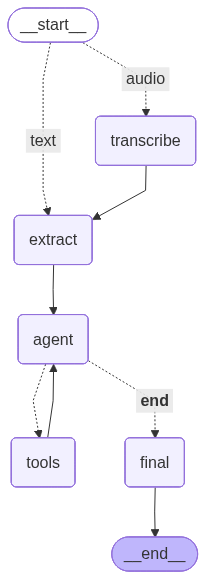

In [46]:
graph

In [ ]:


result = graph.invoke({
    "audio_file": "test.mp4",
    "transcript_format": "audio"
})

In [48]:
result

{'transcript': " Hello, my name is Rohit. I am from Rajasthan Sikar. Currently I am studying at IIT Bombay doing BTEC in Energy Science. I am also learning how AI is changing the world and what's going to happen in the next 7 to 10 years. I am continuously upscaling myself in the AI domain and I also have interest in the energy domain, how energy industry can use AI to enhance the efficiency of systems and other things. Thank you.",
 'audio_file': 'test.mp4',
 'transcript_format': 'audio',
 'summary': "Rohit, a BTEC Energy Science student at IIT Bombay, shared his background and interests in AI's future impact (next 7-10 years) and AI applications in energy industry efficiency. He emphasized continuous upskilling in AI.",
 'action_items': [],
 'participants': ['Rohit'],
 'messages': [HumanMessage(content='\n        Process the following action items using tools as needed.\n        []\n        ', additional_kwargs={}, response_metadata={}, id='53887270-5e1b-400c-85ea-ae5c185e7091'),
  A

In [50]:
result = graph.invoke({
    "transcript": """
uh okay are we all here? yeah i think vikram is joining… yeah hey sorry i’m late

Rohit: no worries, let’s just start… so this is about the launch thing

Ananya: yeah basically we need to finalize stuff today, timeline and all

Vikram: yeah so uh from backend side most things are working but transcription is still kinda slow for long audios

Neha: yeah that’s gonna be a problem because users will upload like 1 hour meetings

Rohit: hmm how bad is it right now

Vikram: like… takes almost real-time or slightly more sometimes

Ananya: that’s not great

Rohit: can we fix it before launch or…

Vikram: yeah i think so, maybe 4–5 days if i focus on it

Rohit: okay so like by monday?

Vikram: yeah monday should be fine

Neha: cool meanwhile i’ll start working on the launch content

Ananya: yeah we’ll need screenshots and demo also

Neha: yeah exactly, and maybe a landing page

Rohit: i can record the demo

Ananya: good

Neha: i’ll take care of the landing page text

Rohit: okay nice

…

Vikram: uh also do we include calendar integration in this release?

Rohit: hmm i’d say no, let’s not complicate

Ananya: yeah +1, we can do that later

Neha: agreed

…

Rohit: so when do we actually launch?

Ananya: if vikram finishes monday then maybe thursday?

Vikram: tight but doable

Neha: yeah works

Rohit: okay so thursday it is

Ananya: yeah

…

Rohit: anything else?

Vikram: nope

Neha: all good

Rohit: cool done

""",
"transcript_format": "text"
})


In [51]:
result

{'transcript': '\nuh okay are we all here? yeah i think vikram is joining… yeah hey sorry i’m late\n\nRohit: no worries, let’s just start… so this is about the launch thing\n\nAnanya: yeah basically we need to finalize stuff today, timeline and all\n\nVikram: yeah so uh from backend side most things are working but transcription is still kinda slow for long audios\n\nNeha: yeah that’s gonna be a problem because users will upload like 1 hour meetings\n\nRohit: hmm how bad is it right now\n\nVikram: like… takes almost real-time or slightly more sometimes\n\nAnanya: that’s not great\n\nRohit: can we fix it before launch or…\n\nVikram: yeah i think so, maybe 4–5 days if i focus on it\n\nRohit: okay so like by monday?\n\nVikram: yeah monday should be fine\n\nNeha: cool meanwhile i’ll start working on the launch content\n\nAnanya: yeah we’ll need screenshots and demo also\n\nNeha: yeah exactly, and maybe a landing page\n\nRohit: i can record the demo\n\nAnanya: good\n\nNeha: i’ll take care o